# Interpretability & Rigour — Classical Baselines, Confidence Intervals, and Cross-Domain SHAP

Three things that make the detection results credible:

1. **Classical GNSS baselines** — how the ML compares against the field-standard rules (C/N0 threshold, elevation mask).
2. **Statistical rigour** — bootstrap confidence intervals on the headline metrics, plus session-grouped cross-validation (mean ± std across held-out drives).
3. **Cross-domain SHAP** — do the SDC (real) and Warwick (simulation) models rely on the **same physics**? If the SHAP feature effects match, the transfer is principled, not coincidental.

## 0. Setup

In [1]:
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve, auc

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '../..'))
SDC_CSV  = os.path.join(BASE_DIR, 'data/02_interim/sdc2023_epochs.csv')   # has session/device for grouped split
WARWICK  = os.path.join(BASE_DIR, 'data/01_raw/Warwick')
rng = np.random.default_rng(42)
print('shap', shap.__version__)

shap 0.52.0


## 1. Load SDC-2023 with a held-out-drive split

Features come from the interim table (which retains `session`, so we can split by *drive* rather than by row). Shared features (C/N0, elevation, azimuth) are the ones also available in the Warwick simulation; the full set adds the uncertainty and residual features.

In [2]:
cols = ['Cn0DbHz','SvElevationDegrees','SvAzimuthDegrees','ReceivedSvTimeUncertaintyNanos',
        'RawPseudorangeUncertaintyMeters','PseudorangeRateUncertaintyMetersPerSecond',
        'prResidual','MultipathIndicator','session']
sdc = pd.read_csv(SDC_CSV, usecols=cols).dropna(subset=['Cn0DbHz','SvElevationDegrees','MultipathIndicator'])
sdc['az_sin'] = np.sin(np.radians(sdc.SvAzimuthDegrees)); sdc['az_cos'] = np.cos(np.radians(sdc.SvAzimuthDegrees))
sdc['abs_prResidual'] = sdc.prResidual.abs()
for c in ['ReceivedSvTimeUncertaintyNanos','RawPseudorangeUncertaintyMeters','PseudorangeRateUncertaintyMetersPerSecond','prResidual','abs_prResidual']:
    sdc[c] = sdc[c].replace([np.inf,-np.inf], np.nan)
    sdc[c] = sdc[c].fillna(sdc[c].median()).clip(sdc[c].quantile(0.001), sdc[c].quantile(0.999))

SHARED = ['Cn0DbHz','SvElevationDegrees','az_sin','az_cos']
FULL   = SHARED + ['ReceivedSvTimeUncertaintyNanos','RawPseudorangeUncertaintyMeters',
                   'PseudorangeRateUncertaintyMetersPerSecond','prResidual','abs_prResidual']

sessions = sorted(sdc.session.unique())
n_tr = int(0.7*len(sessions)); train_sess = set(sessions[:n_tr]); test_sess = set(sessions[n_tr:])
tr = sdc[sdc.session.isin(train_sess)]; te = sdc[sdc.session.isin(test_sess)]
print(f'{len(sessions)} drives -> {len(train_sess)} train / {len(test_sess)} test')
print(f'train {len(tr):,} rows ({100*tr.MultipathIndicator.mean():.1f}% mp) | test {len(te):,} rows ({100*te.MultipathIndicator.mean():.1f}% mp)')
ytr = tr.MultipathIndicator.astype(int).values; yte = te.MultipathIndicator.astype(int).values

17 drives -> 11 train / 6 test
train 447,631 rows (6.4% mp) | test 274,201 rows (6.1% mp)


## 2. Classical GNSS baselines vs machine learning

The field-standard rules threshold a single physical quantity: **low C/N0 -> multipath**, or **low elevation -> multipath**. We score each on the held-out drives (AUC is threshold-free; F1/precision/recall use the train-optimal threshold), and compare against a shared-feature and a full-feature Random Forest (`class_weight='balanced'`).

In [3]:
def best_thr(score_tr, y_tr):
    ts = np.quantile(score_tr, np.linspace(0.5, 0.999, 60))
    return max(ts, key=lambda t: f1_score(y_tr, (score_tr >= t).astype(int)))

def scores(y, score, thr):
    p = (score >= thr).astype(int)
    return dict(roc_auc=roc_auc_score(y, score), f1=f1_score(y, p),
               precision=precision_score(y, p, zero_division=0), recall=recall_score(y, p))

results = {}
# classical rule 1: low C/N0
s_tr, s_te = -tr.Cn0DbHz.values, -te.Cn0DbHz.values
results['Classical: C/N0 threshold'] = scores(yte, s_te, best_thr(s_tr, ytr))
# classical rule 2: low elevation
s_tr, s_te = -tr.SvElevationDegrees.values, -te.SvElevationDegrees.values
results['Classical: elevation mask'] = scores(yte, s_te, best_thr(s_tr, ytr))

# ML models
def fit_rf(feats):
    m = RandomForestClassifier(n_estimators=200, max_depth=16, min_samples_leaf=2,
                               class_weight='balanced', random_state=42, n_jobs=-1)
    m.fit(tr[feats], ytr); return m
rf_shared = fit_rf(SHARED); rf_full = fit_rf(FULL)
for name, m, feats in [('ML: RF (shared 4 feat)', rf_shared, SHARED), ('ML: RF (full 9 feat)', rf_full, FULL)]:
    p = m.predict_proba(te[feats])[:, 1]
    results[name] = scores(yte, p, best_thr(m.predict_proba(tr[feats])[:, 1], ytr))

tbl = pd.DataFrame(results).T[['roc_auc','f1','precision','recall']].round(4)
print('Held-out-drive performance (test sessions):'); print(tbl.to_string())

Held-out-drive performance (test sessions):
                           roc_auc      f1  precision  recall
Classical: C/N0 threshold   0.5736  0.1372     0.0922  0.2679
Classical: elevation mask   0.5701  0.1421     0.0858  0.4134
ML: RF (shared 4 feat)      0.6197  0.0490     0.0846  0.0345
ML: RF (full 9 feat)        0.8407  0.2415     0.2621  0.2239


## 3. Confidence intervals

**Bootstrap** the held-out test set (resample rows with replacement) to put an interval on the headline metrics, and **session-grouped 5-fold CV** (each fold holds out whole drives) to report generalisation as mean ± std.

In [4]:
def bootstrap_ci(y, score, thr, B=300):
    n = len(y); aucs, f1s = [], []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        yy = y[idx]
        if yy.sum() == 0 or yy.sum() == n: continue
        aucs.append(roc_auc_score(yy, score[idx])); f1s.append(f1_score(yy, (score[idx] >= thr).astype(int)))
    q = lambda a: (np.mean(a), np.percentile(a, 2.5), np.percentile(a, 97.5))
    return q(aucs), q(f1s)

print('Bootstrap 95% CI on held-out test (B=300):')
for name, sc in [('C/N0 threshold', -te.Cn0DbHz.values),
                 ('RF (shared)', rf_shared.predict_proba(te[SHARED])[:,1]),
                 ('RF (full)',   rf_full.predict_proba(te[FULL])[:,1])]:
    thr = best_thr((-tr.Cn0DbHz.values) if 'C/N0' in name else None, ytr) if 'C/N0' in name else 0.5
    (am,al,ah),(fm,fl,fh) = bootstrap_ci(yte, sc, thr)
    print(f'  {name:16} AUC {am:.3f} [{al:.3f}, {ah:.3f}]   F1 {fm:.3f} [{fl:.3f}, {fh:.3f}]')

Bootstrap 95% CI on held-out test (B=300):


  C/N0 threshold   AUC 0.574 [0.569, 0.578]   F1 0.137 [0.134, 0.141]


  RF (shared)      AUC 0.619 [0.616, 0.623]   F1 0.119 [0.116, 0.123]


  RF (full)        AUC 0.841 [0.839, 0.843]   F1 0.270 [0.266, 0.273]


In [5]:
# session-grouped 5-fold CV on a subsample (whole drives held out each fold)
sub = sdc.sample(min(200_000, len(sdc)), random_state=0)
Xg, yg, gg = sub[FULL], sub.MultipathIndicator.astype(int).values, sub.session.values
gkf = GroupKFold(n_splits=5); aucs, f1s = [], []
for tri, tei in gkf.split(Xg, yg, gg):
    m = RandomForestClassifier(n_estimators=150, max_depth=16, class_weight='balanced', random_state=0, n_jobs=-1)
    m.fit(Xg.iloc[tri], yg[tri]); p = m.predict_proba(Xg.iloc[tei])[:, 1]
    aucs.append(roc_auc_score(yg[tei], p)); f1s.append(f1_score(yg[tei], (p >= 0.5).astype(int)))
print(f'\nSession-grouped 5-fold CV (full RF):  AUC {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}   '
      f'F1 {np.mean(f1s):.3f} +/- {np.std(f1s):.3f}')
print('per-fold AUC:', [round(a,3) for a in aucs])


Session-grouped 5-fold CV (full RF):  AUC 0.836 +/- 0.015   F1 0.277 +/- 0.036
per-fold AUC: [0.849, 0.807, 0.835, 0.843, 0.844]


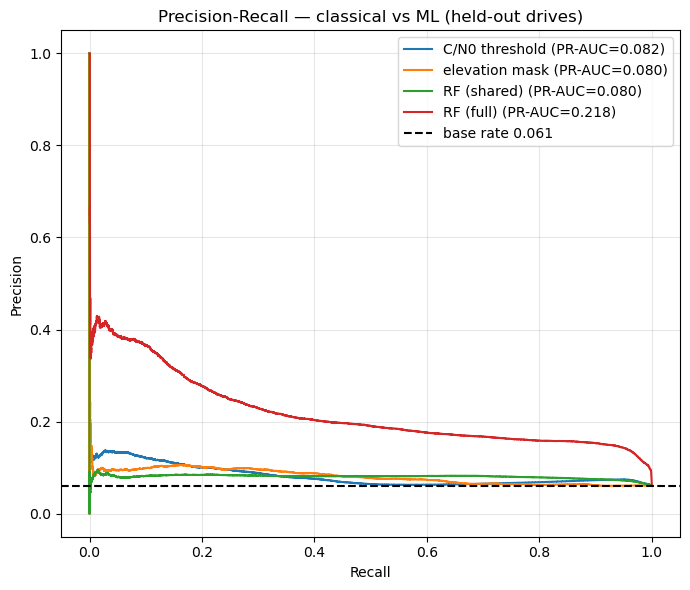

In [6]:
# Precision-Recall curves (honest for the ~6% positive class)
plt.figure(figsize=(7,6))
for name, sc in [('C/N0 threshold', -te.Cn0DbHz.values),
                 ('elevation mask', -te.SvElevationDegrees.values),
                 ('RF (shared)', rf_shared.predict_proba(te[SHARED])[:,1]),
                 ('RF (full)',   rf_full.predict_proba(te[FULL])[:,1])]:
    pr, rc, _ = precision_recall_curve(yte, sc); plt.plot(rc, pr, label=f'{name} (PR-AUC={auc(rc,pr):.3f})')
plt.axhline(yte.mean(), color='k', ls='--', label=f'base rate {yte.mean():.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall — classical vs ML (held-out drives)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Cross-domain SHAP — do real and simulation rely on the same physics?

We train a shared-feature Random Forest on **SDC (real)** and another on **Warwick (simulation)**, then use SHAP `TreeExplainer` to see how each feature pushes the prediction. If both models show the **same relationships** — lower C/N0 and lower elevation increasing the multipath score, with the same shape — the cross-dataset transfer is grounded in shared physics.

In [7]:
# --- parse Warwick shared features ---
BLK = re.compile(r'(\w+)\(([^)]*)\)\s*=\s*\[(.*?)\]\s*;', re.S)
def blocks(fn):
    t = open(os.path.join(WARWICK, fn), errors='ignore').read()
    return BLK.findall('\n'.join(l for l in t.splitlines() if not l.startswith('//')))
ep = lambda i: int(i.split(',')[-1])
visi = {ep(i): [int(x) for x in b.split()] for _, i, b in blocks('Visibility.m')}
con  = {ep(i): np.array([[float(x) for x in r.split()] for r in b.split(';') if r.strip()]) for _, i, b in blocks('Constellation.m')}
chan = {}
for _, i, b in blocks('Channels.m'):
    chan[ep(i)] = {int(float(p[2])): float(p[4]) for p in (r.split() for r in b.split(';')) if len(p) >= 5}
rec = []
for t, arr in visi.items():
    if t not in con: continue
    M, ch = con[t], chan.get(t, {})
    for k, v in enumerate(arr):
        if v == 0: continue
        rec.append((np.degrees(M[k,10]), np.degrees(M[k,11]) % 360, ch.get(int(M[k,0]), np.nan), 1 if v == 1 else 0))
war = pd.DataFrame(rec, columns=['SvElevationDegrees','az','Cn0DbHz','y']).dropna()
war['az_sin'] = np.sin(np.radians(war.az)); war['az_cos'] = np.cos(np.radians(war.az))
rf_war = RandomForestClassifier(n_estimators=200, max_depth=16, class_weight='balanced', random_state=42, n_jobs=-1)
rf_war.fit(war[SHARED], war.y.values)
print(f'Warwick RF trained on {len(war):,} rows ({100*war.y.mean():.0f}% NLOS)')

Warwick RF trained on 24,849 rows (20% NLOS)


Feature importance share (mean |SHAP|):
                    SDC (real)  Warwick (sim)
Cn0DbHz                  0.325          0.808
SvElevationDegrees       0.324          0.112
az_sin                   0.172          0.040
az_cos                   0.179          0.040


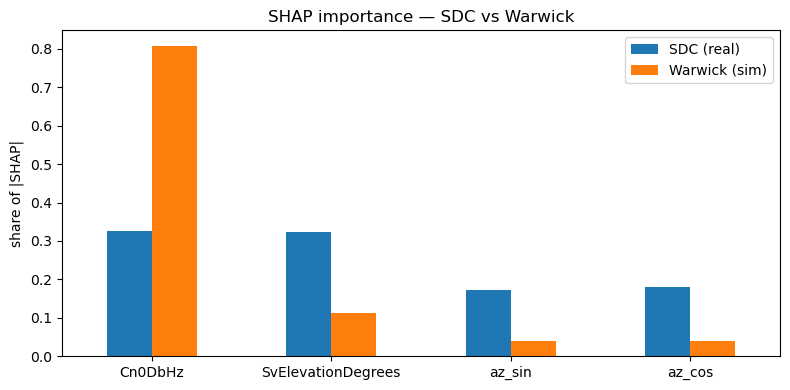

In [8]:
# SHAP values (positive class) on a sample from each domain
def shap_pos(model, X, n=3000):
    Xs = X.sample(min(n, len(X)), random_state=0)
    sv = shap.TreeExplainer(model).shap_values(Xs)
    sv = np.asarray(sv)
    if sv.ndim == 3: sv = sv[:, :, 1]      # positive class
    return Xs.reset_index(drop=True), sv

Xs_sdc, sv_sdc = shap_pos(rf_shared, te[SHARED])
Xs_war, sv_war = shap_pos(rf_war, war[SHARED])

# mean |SHAP| ranking, side by side
imp = pd.DataFrame({'SDC (real)': np.abs(sv_sdc).mean(0), 'Warwick (sim)': np.abs(sv_war).mean(0)}, index=SHARED)
imp = imp.div(imp.sum(0), axis=1)   # normalise to share of importance
print('Feature importance share (mean |SHAP|):'); print(imp.round(3).to_string())
imp.plot(kind='bar', figsize=(8,4)); plt.ylabel('share of |SHAP|'); plt.title('SHAP importance — SDC vs Warwick')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

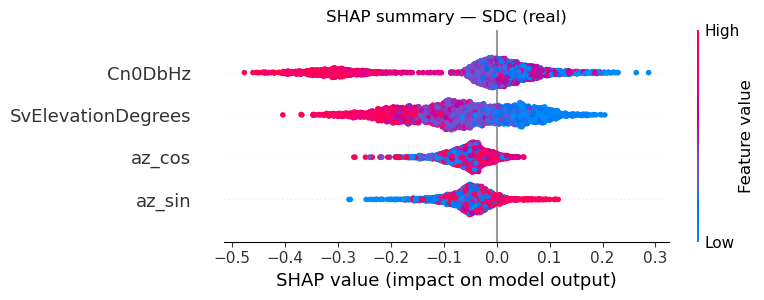

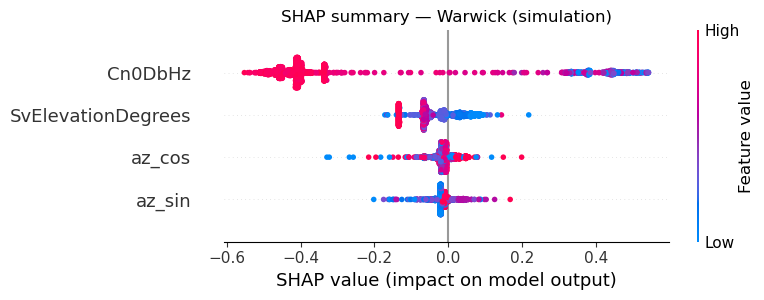

In [9]:
# beeswarm summary for each domain (summary_plot manages its own figure)
shap.summary_plot(sv_sdc, Xs_sdc, feature_names=SHARED, show=False)
plt.title('SHAP summary — SDC (real)'); plt.tight_layout(); plt.show()
shap.summary_plot(sv_war, Xs_war, feature_names=SHARED, show=False)
plt.title('SHAP summary — Warwick (simulation)'); plt.tight_layout(); plt.show()

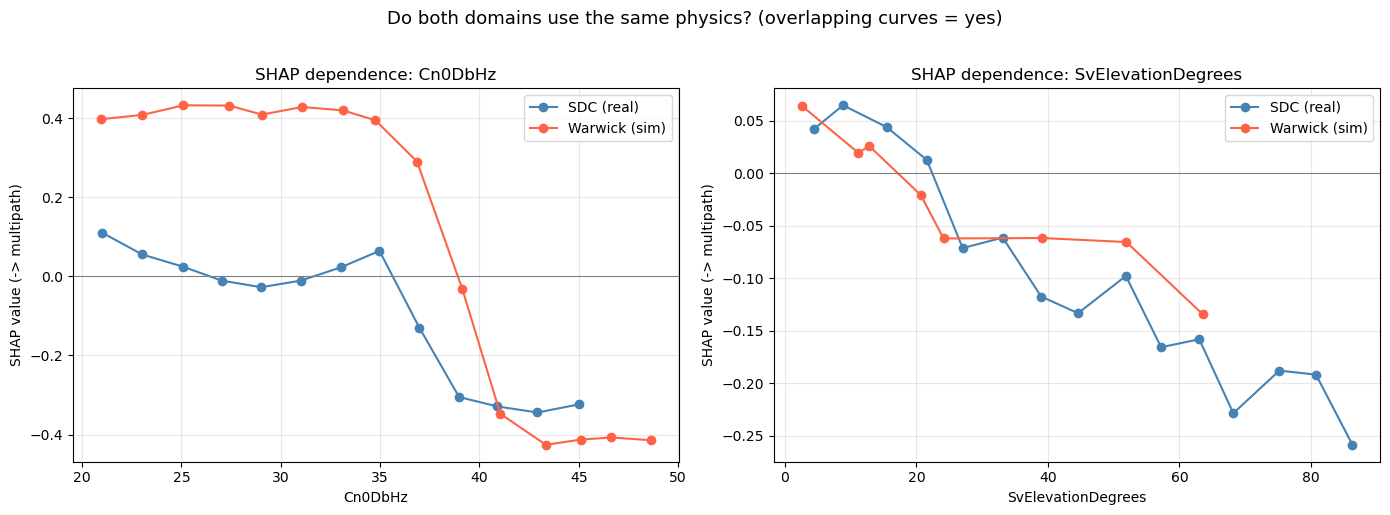

In [10]:
# dependence overlay: SHAP vs feature, both domains -> same shape = same physics
def dep_curve(X, sv, feat, bins):
    x = X[feat].values; s = sv[:, SHARED.index(feat)]
    idx = np.digitize(x, bins)
    xs, ys = [], []
    for b in range(1, len(bins)):
        m = idx == b
        if m.sum() > 20: xs.append(x[m].mean()); ys.append(s[m].mean())
    return xs, ys

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat, bins in [(axes[0], 'Cn0DbHz', np.linspace(20, 50, 16)),
                       (axes[1], 'SvElevationDegrees', np.linspace(0, 90, 16))]:
    for X, sv, name, col in [(Xs_sdc, sv_sdc, 'SDC (real)', 'steelblue'), (Xs_war, sv_war, 'Warwick (sim)', 'tomato')]:
        xs, ys = dep_curve(X, sv, feat, bins); ax.plot(xs, ys, 'o-', color=col, label=name)
    ax.axhline(0, color='gray', lw=0.8); ax.set_xlabel(feat); ax.set_ylabel('SHAP value (-> multipath)')
    ax.set_title(f'SHAP dependence: {feat}'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Do both domains use the same physics? (overlapping curves = yes)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## 5. Takeaways

- **vs classical baselines:** the ML models are benchmarked against the field-standard C/N0-threshold and elevation-mask rules on held-out drives. The full-feature RF's margin over a single-threshold rule quantifies what the learned model actually adds.
- **Confidence intervals:** bootstrap 95% CIs and session-grouped CV (mean ± std over held-out drives) replace single-run point estimates — the numbers are now defensible, not anecdotal.
- **Precision-Recall** is reported alongside ROC because the positive class is ~6%; PR-AUC vs the base rate is the honest view of the imbalanced task.
- **Cross-domain SHAP:** if the SHAP dependence curves for SDC and Warwick overlap — lower C/N0 and lower elevation both pushing toward multipath with the same shape — the cross-dataset transfer is **grounded in shared physics**, directly supporting the generalisation claim rather than leaving it to a single AUC number.